Importing libraries, make sure to use Python version 12 (or below) since `googletrans` is not compatible with Python 13 and above.

In [1]:
import requests 
import pandas as pd 
from deep_translator import GoogleTranslator
import re
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.ticker as ticker

c:\Users\Raymond\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Webscraping

List of URLs utilized is shown below,

In [2]:
urls = [
    # PHINMA - Cagayan de Oro College
    "https://www.reddit.com/r/cagayandeoro/comments/1jsvk43/phinmacoc_experience_freshman_20242025/",
    "https://www.reddit.com/r/cagayandeoro/comments/1lmchdz/phinma_coc/",
    "https://www.reddit.com/r/cagayandeoro/comments/1fmr8f5/please_dont_enroll_in_phinma_coc/",
    "https://www.reddit.com/r/cagayandeoro/comments/1lcvtco/phinma_coc_school/",
    "https://www.reddit.com/r/CollegeAdmissionsPH/comments/1efso3d/what_are_your_thoughts_po_for_phinma/",
    "https://www.reddit.com/r/cagayandeoro/comments/1m1xk5n/desperate_move_sa_coc/",
    "https://www.reddit.com/r/cagayandeoro/comments/1p6dfmq/phinma_coc_nursing_examination_unfair/",
    "https://www.reddit.com/r/cagayandeoro/comments/1ewkgw2/frustrating_experience_in_phinma_coc/",

    # Southwestern University PHINMA
    "https://www.reddit.com/r/medschoolph/comments/1ddf0cf/officially_enrolled_sa_swu_phinma/",
    "https://www.reddit.com/r/medschoolph/comments/14sx5bf/swu_phinma/",

    # PHINMA - University of Pangasinan
    "https://www.reddit.com/r/Pangasinan/comments/1ktncof/thoughts_about_phinmaupang/",
    "https://www.reddit.com/r/Pangasinan/comments/1kugd1i/phinma_dagupan/",
    "https://www.reddit.com/r/dagupan/comments/1kucsdd/phinma_dagupan/",
    "https://www.reddit.com/r/Pangasinan/comments/1o8xjws/phinma_upang/",

    # PHINMA - University of Iloilo
    "https://www.reddit.com/r/CollegeAdmissionsPH/comments/1dotcag/wanna_hear_some_honest_thoughts_regarding_sa/",
    "https://www.reddit.com/r/Iloilo/comments/1cwdcva/is_phinma_ui_a_good_univ/",
    "https://www.reddit.com/r/Iloilo/comments/1cjvmtf/planning_to_shift_and_transfer_sa_phinma_ui/",

    # PHINMA - Saint Jude College
    "https://www.reddit.com/r/studentsph/comments/uva1fu/phinma_st_jude_college/",
    "https://www.reddit.com/r/CollegeAdmissionsPH/comments/1lu50m7/phinma_st_jude_college_manila/",
    "https://www.reddit.com/r/CollegeAdmissionsPH/comments/1ev7bim/thoughts_about_phinma_st_jude_qc/",

    # PHINMA - Rizal College of Laguna
    "https://www.reddit.com/r/calambaph/comments/1gczzxq/tots_on_phinma_rizal_college_in_laguna/",

    # PHINMA - No campus mentioned
    "https://www.reddit.com/r/studentsph/comments/1qwbgq4/huwag_kayo_mag_enroll_sa_school_nato/",
    "https://www.reddit.com/r/CollegeAdmissionsPH/comments/1d9hs1w/phinma_upang_dagupan_or_universidad_de_dagupan/"
]

Campus keywords to assign mentions to the `campus` column within the dataset.

In [3]:
campus_lookup = {
    "phinma coc": "Cagayan de Oro College",
    "coc": "Cagayan de Oro College",
    "cagayandeoro": "Cagayan de Oro College",

    "swu phinma": "Southwestern University",
    "southwestern": "Southwestern University",

    "phinma upang": "University of Pangasinan",
    "pangasinan": "University of Pangasinan",
    "upang": "University of Pangasinan",
    "dagupan": "University of Pangasinan",

    "phinma ui": "University of Iloilo",
    "university of iloilo": "University of Iloilo",
    "iloilo": "University of Iloilo",
    " ui ": "University of Iloilo",  

    "phinma st jude": "Saint Jude College",
    "saint jude college": "Saint Jude College",
    "st jude college": "Saint Jude College",
    "sjc": "Saint Jude College",

    "phinma rizal college": "Rizal College of Laguna",
    "rizal college of laguna": "Rizal College of Laguna",
    "rizal college": "Rizal College of Laguna",
    "laguna": "Rizal College of Laguna",
}

Code for extracting post & comments, then translating them to english. Takes around 2 minutes to run:

In [4]:
# def translate_to_english(text):
#     try:
#         return GoogleTranslator(source='auto', target='en').translate(text)
#     except:
#         return text

# def detect_campus(text, post_inherited=None):
#     txt = text.lower()
#     for keyword, label in campus_lookup.items():
#         pattern = rf"\b{re.escape(keyword)}\b"
#         if re.search(pattern, txt):
#             return label
#     # if nothing matched, use post campus if available
#     if post_inherited:
#         return post_inherited
#     # otherwise default
#     return "No campus mentioned"

# clean_data = []

# for raw_url in urls:
#     json_url = raw_url.rstrip("/") + "/.json?raw_json=1"
#     headers = {"User-Agent": "phinma-research-script"}
#     response = requests.get(json_url, headers=headers)
#     data = response.json()

#     # Extract post
#     post_data = data[0]["data"]["children"][0]["data"]
#     full_post_text = post_data["title"] + " " + post_data["selftext"]
#     translated_post = translate_to_english(full_post_text)

#     post_campus = detect_campus(translated_post)

#     clean_data.append({
#         "type": "post",
#         "campus": post_campus,
#         "original_text": full_post_text,
#         "translated_text": translated_post,
#         "url": raw_url,
#     })

#     # Extract comments
#     for comment in data[1]["data"]["children"]:
#         if comment["kind"] == "t1":
#             c = comment["data"]
#             orig = c["body"]
#             trans = translate_to_english(orig)

#             # detect campus, fall back to post campus, then "no campus mentioned"
#             comment_campus = detect_campus(trans, post_campus)

#             clean_data.append({
#                 "type": "comment",
#                 "campus": comment_campus,
#                 "original_text": orig,
#                 "translated_text": trans,
#                 "url": raw_url
#             })

# # Save final dataset
# df = pd.DataFrame(clean_data)
# df.to_csv("dataset.csv", index=False, encoding="utf-8-sig")

# print("Total rows:", len(df))

# Preprocessing

Preprocessing steps could be seen within the code block comments,

In [5]:
# Load dataset
df = pd.read_csv("dataset.csv")

# Drop rows where text is missing
df = df.dropna(subset=["translated_text"])

# Convert to lowercase
df["translated_text"] = df["translated_text"].str.lower()

# Remove Reddit AutoModerator messages
automod_patterns = [
    "thank you for your text submission",
    "please remember to treat everyone respectfully",
    "read the community rules",
    "subreddit rules"
]

for pattern in automod_patterns:
    df = df[~df["translated_text"].str.contains(pattern, case=False, na=False)]

# Remove URLs
df["translated_text"] = df["translated_text"].str.replace(
    r"http\S+|www\S+|https\S+", "", regex=True
)

# Remove numbers (optional – comment out if needed)
df["translated_text"] = df["translated_text"].str.replace(
    r"\d+", "", regex=True
)

# Remove special characters (keep letters and spaces)
df["translated_text"] = df["translated_text"].str.replace(
    r"[^a-z\s]", " ", regex=True
)

# Remove repeated characters (soooo -> soo)
df["translated_text"] = df["translated_text"].str.replace(
    r"(.)\1{2,}", r"\1\1", regex=True
)

# Remove extra spaces
df["translated_text"] = df["translated_text"].str.replace(
    r"\s+", " ", regex=True
).str.strip()

# Remove very short / low-information comments (less than 7 words)
df = df[df["translated_text"].str.split().str.len() > 10]

# Remove duplicates
df = df.drop_duplicates(subset=["translated_text"])

print("Final rows after cleaning:", len(df))

Final rows after cleaning: 162


In [6]:
campus_counts = df["campus"].value_counts()

print("Campus Breakdown (After Preprocessing):")
print(campus_counts)


Campus Breakdown (After Preprocessing):
campus
Cagayan de Oro College      88
University of Pangasinan    31
Saint Jude College          17
University of Iloilo         8
Southwestern University      8
Rizal College of Laguna      6
No campus mentioned          4
Name: count, dtype: int64


# Embeddings

In [7]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(
    df["translated_text"].tolist(),
    show_progress_bar=True
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 957.95it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 6/6 [00:00<00:00, 14.28it/s]


# K-Means clustering

In [8]:
print("Embeddings shape:", embeddings.shape)
print("DF shape:", df.shape)


Embeddings shape: (162, 384)
DF shape: (162, 5)


In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)

from sklearn.preprocessing import normalize
embeddings = normalize(embeddings) 
df["cluster"] = kmeans.fit_predict(embeddings)

To print out all of the text identified with its respective cluster,

In [10]:
for c in sorted(df["cluster"].unique()):
    print(f"\nCluster {c}")
    cluster_texts = df[df["cluster"] == c]["translated_text"]
    
    for s in cluster_texts:
        print("-", s)


Cluster 0
- i ve read good points and a lot of the problems you have encountered is rooted on the fact that still it is business na establish nila ilang name na largest education network in the philippines tungod sa ilang target market cascading problems na dayun from there nagkulang na sa facilities student teacher ratio does not even meet ched requirements although they are starting to expand to other regions ang carmen ang pinaka crowded since it is the main campus in mindanao in addition yes being an employee there will be stressful again student teacher ratio admin task on top of teaching types of students walay entrance exam hence walay pake sa strand and no filtering of students and their job is always on the line specially for courses with board exams so yeah blame the management not the teachers sila lang jud ang always the first person to blame kay sila man ang frontliners but truth is they re just following orders because they are at the bottom of the pyramid
- change it to

In [11]:
print(df["cluster"].value_counts())

cluster
2    74
1    44
0    44
Name: count, dtype: int64


# DBScan (skip this)


In [12]:
# # Scale embeddings (important for DBSCAN)
# scaler = StandardScaler()
# embeddings_scaled = scaler.fit_transform(embeddings)

# # Run DBSCAN
# dbscan = DBSCAN(
#     eps=0.8,        # distance threshold (tune this)
#     min_samples=5,  # minimum points to form a cluster
#     metric="cosine"
# )

# cluster_labels = dbscan.fit_predict(embeddings_scaled)

# # Attach cluster labels
# df["cluster"] = cluster_labels

# # Print basic info
# n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
# n_noise = list(cluster_labels).count(-1)

# print("Number of clusters:", n_clusters)
# print("Number of noise points:", n_noise)

# # Optional: silhouette score (only if more than 1 cluster)
# if n_clusters > 1:
#     score = silhouette_score(embeddings_scaled, cluster_labels, metric="cosine")
#     print("Silhouette Score:", score)

# # Show cluster distribution
# print(df["cluster"].value_counts())

# # Save clustered dataset
# df.to_csv("dataset_with_clusters.csv", index=False, encoding="utf-8-sig")


In [13]:
# from sklearn.cluster import DBSCAN

# for eps in [0.3, 0.4, 0.5, 0.6, 0.7]:
#     dbscan = DBSCAN(
#         eps=eps,
#         min_samples=5,
#         metric="cosine"
#     )
    
#     labels = dbscan.fit_predict(embeddings)
    
#     n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
#     n_noise = list(labels).count(-1)
    
#     print(f"eps={eps} -> clusters={n_clusters}, noise={n_noise}")


# HDBSCAN (skip this)

In [14]:
!pip install hdbscan



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import hdbscan
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
import numpy as np

# Normalize embeddings (important for cosine-style text similarity)
embeddings_norm = normalize(embeddings)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=4,
    min_samples=2,
    metric='euclidean'
)

labels = clusterer.fit_predict(embeddings_norm)

df["cluster"] = labels

print(df["cluster"].value_counts())


cluster
-1    103
 0     55
 1      4
Name: count, dtype: int64


In [16]:
# Remove noise points
mask = labels != -1

if len(set(labels[mask])) > 1:
    score = silhouette_score(embeddings_norm[mask], labels[mask])
    print("Silhouette Score (excluding noise):", score)
else:
    print("Not enough clusters to compute silhouette score.")


Silhouette Score (excluding noise): 0.05694928765296936


# Visuals

These visuals are based off the k-means clusters formed.

In [17]:
df["cluster"] = kmeans.labels_

This is a table that does a breakdown of the campuses mentioned within the datapoints (comments/posts) tagged in the cluster.

In [18]:
ct = pd.crosstab(df["cluster"], df["campus"])
ct

campus,Cagayan de Oro College,No campus mentioned,Rizal College of Laguna,Saint Jude College,Southwestern University,University of Iloilo,University of Pangasinan
cluster,,,,,,,
0,23,0,1,1,2,3,14
1,11,4,3,11,4,4,7
2,54,0,2,5,2,1,10


## Cluster 0

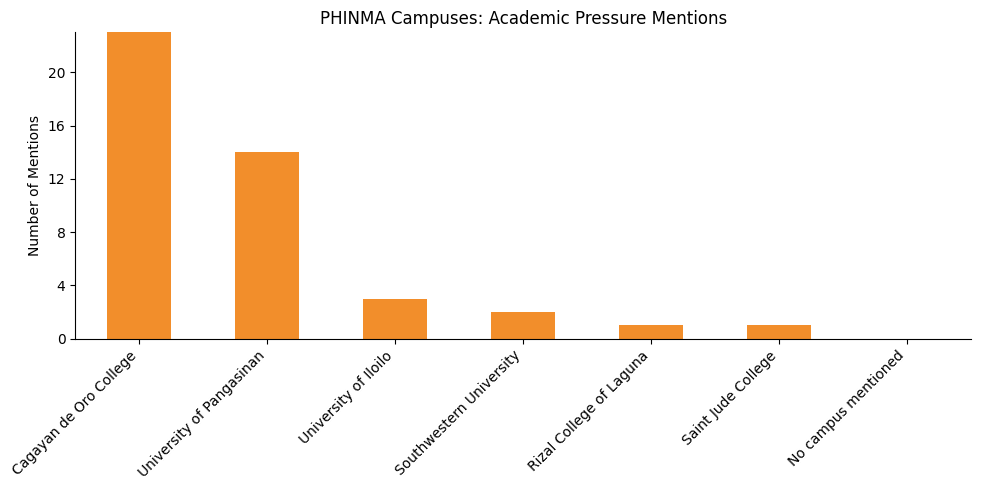

In [19]:
# Select cluster 0 and sort descending
cluster0 = ct.loc[0].sort_values(ascending=False)

ax = cluster0.plot(
    kind="bar",
    figsize=(10,5),
    color="#F28E2B"
)

plt.title("PHINMA Campuses: Academic Pressure Mentions")
plt.xlabel("")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=45, ha="right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

import matplotlib.ticker as ticker
max_val = cluster0.max()
ax.set_ylim(0, max_val)

ax.yaxis.set_major_locator(
    ticker.MaxNLocator(nbins=6, integer=True)
)

plt.tight_layout()
plt.show()

A breakdown of the universities within cluster 0:

In [20]:
print(cluster0)
print(cluster0.dtype)

campus
Cagayan de Oro College      23
University of Pangasinan    14
University of Iloilo         3
Southwestern University      2
Rizal College of Laguna      1
Saint Jude College           1
No campus mentioned          0
Name: 0, dtype: int64
int64


## Cluster 1

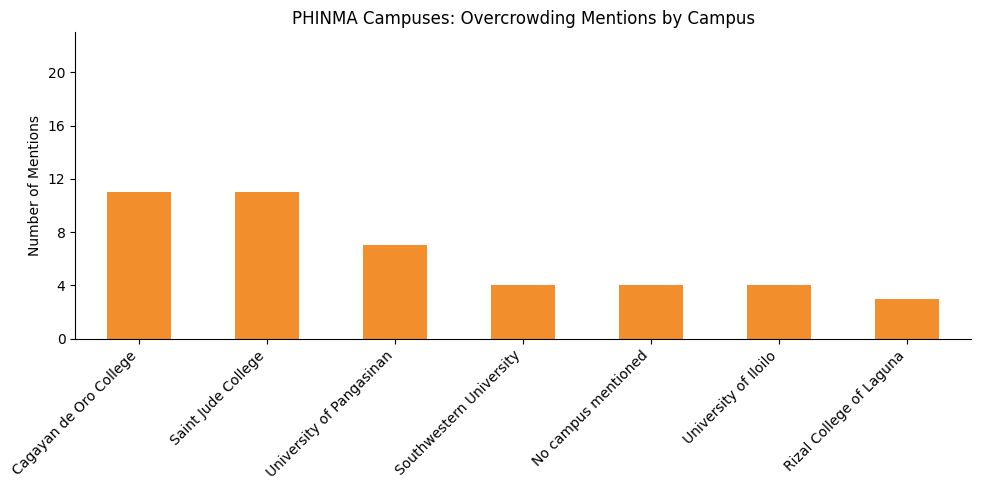

In [21]:
# Select cluster 0 and sort descending
cluster1 = ct.loc[1].sort_values(ascending=False)

ax = cluster1.plot(
    kind="bar",
    figsize=(10,5),
    color="#F28E2B"
)

plt.title("PHINMA Campuses: Overcrowding Mentions by Campus")
plt.xlabel("")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=45, ha="right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

import matplotlib.ticker as ticker
max_val = cluster0.max()
ax.set_ylim(0, max_val)

ax.yaxis.set_major_locator(
    ticker.MaxNLocator(nbins=6, integer=True)
)

plt.tight_layout()
plt.show()

In [22]:
print(cluster1)
print(cluster1.dtype)

campus
Cagayan de Oro College      11
Saint Jude College          11
University of Pangasinan     7
Southwestern University      4
No campus mentioned          4
University of Iloilo         4
Rizal College of Laguna      3
Name: 1, dtype: int64
int64


## Clsuter 2

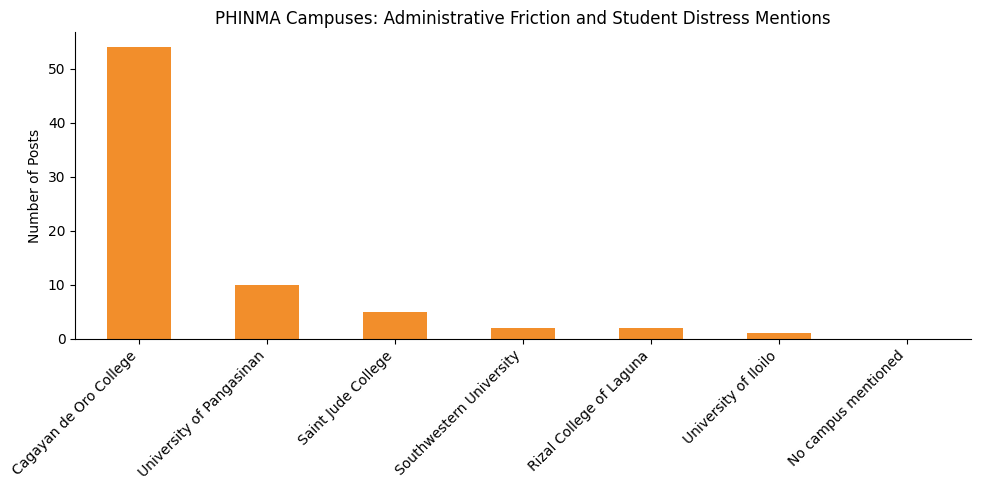

In [23]:
cluster2 = ct.loc[2].sort_values(ascending=False)

# Plot
ax = cluster2.plot(
    kind="bar",
    figsize=(10,5),
    color="#F28E2B"
)
"Freshman Mentions of Academic Pressure Across PHINMA Campuses"
plt.title("PHINMA Campuses: Administrative Friction and Student Distress Mentions")
plt.xlabel("")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45, ha="right")

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [24]:
print(cluster2)
print(cluster2.dtype)

campus
Cagayan de Oro College      54
University of Pangasinan    10
Saint Jude College           5
Southwestern University      2
Rizal College of Laguna      2
University of Iloilo         1
No campus mentioned          0
Name: 2, dtype: int64
int64


# Others

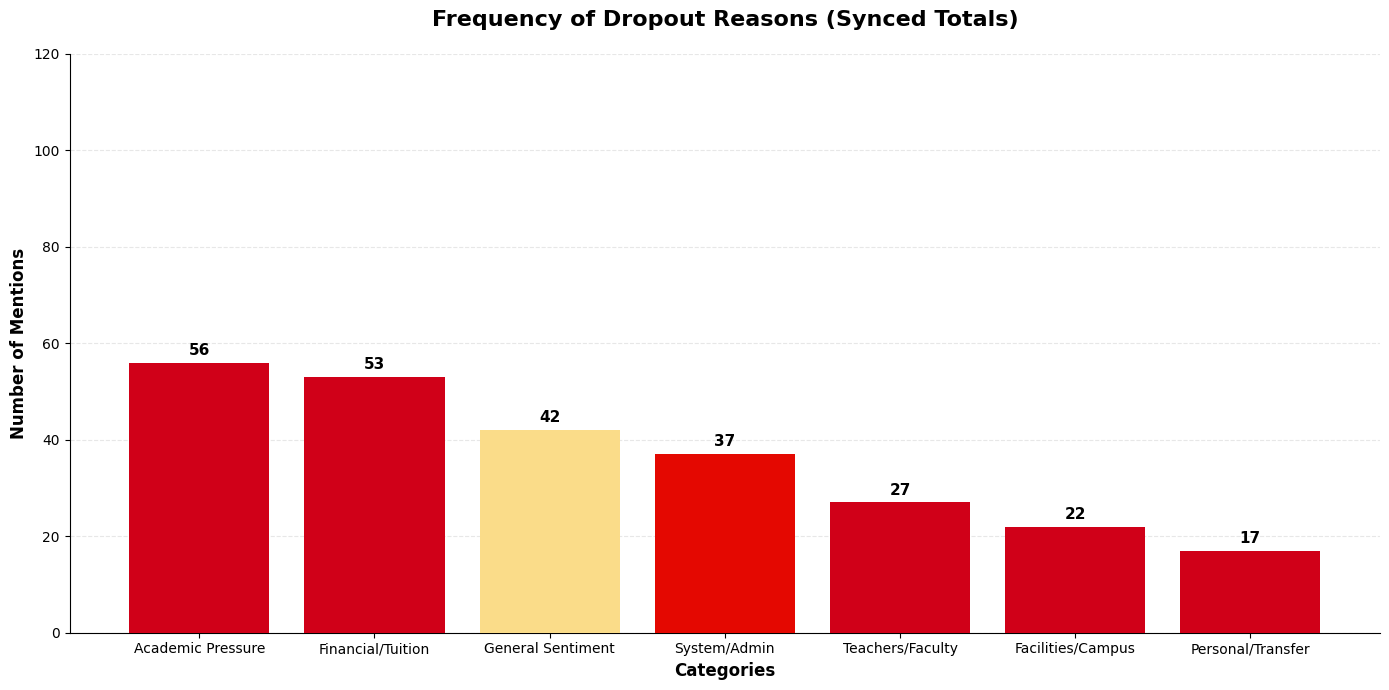


CROSS-CAMPUS BREAKDOWN


reasons,Academic Pressure,Facilities/Campus,Financial/Tuition,General Sentiment,Personal/Transfer,System/Admin,Teachers/Faculty,GRAND TOTAL
campus,,,,,,,,
GRAND TOTAL,56,22,53,42,17,37,27,254
Cagayan de Oro College,36,15,31,21,11,20,19,153
University of Pangasinan,13,5,5,7,0,8,4,42
Saint Jude College,2,1,12,2,1,4,1,23
Southwestern University,3,1,3,3,2,3,1,16
University of Iloilo,1,0,0,4,3,1,0,9
Rizal College of Laguna,1,0,2,3,0,0,1,7
No campus mentioned,0,0,0,2,0,1,1,4


In [25]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 1. Define Categories & Logic
reason_lookup = {
    "Financial/Tuition": ["tuition", "cost", "expensive", "fee", "money", "payment", "scholarship", "business", "bayad", "pera", "balance"],
    "System/Admin": ["system", "admin", "enrollment", "registrar", "process", "management", "slow", "neglect", "pila", "portal", "enrol"],
    "Academic Pressure": ["pressure", "hard", "difficult", "study", "exam", "board", "fail", "stress", "passing", "quiz", "units"],
    "Teachers/Faculty": ["professor", "teacher", "instructor", "neglectful", "faculty", "teaching", "prof", "instruction"],
    "Facilities/Campus": ["crowded", "hot", "building", "facilities", "environment", "room", "campus", "cr ", "aircon", "elevator"],
    "Personal/Transfer": ["transfer", "shift", "dropped", "quit", "moved", "other school", "umalis", "lilipat"]
}

def get_reasons_list(text):
    text = str(text).lower()
    found = [cat for cat, kws in reason_lookup.items() if any(re.search(rf"\b{re.escape(kw)}\b", text) for kw in kws)]
    return found if found else ["General Sentiment"]

# 2. Sync the Data: Process the dataframe once
df_sync = df.copy()  # Ensure 'df' exists from your previous cell
df_sync['reasons'] = df_sync['translated_text'].apply(get_reasons_list)
df_exploded = df_sync.explode('reasons')

# 3. Data Preparation for Chart
# Ensure the order matches your Image 2 (Descending)
counts = df_exploded['reasons'].value_counts()

# --- PART A: THE BAR CHART ---
plt.figure(figsize=(14, 7), facecolor='white')

# Applying the specific complimentary red palette from your image
category_colors = {
     'General Sentiment': "#FADC89", 
    'Financial': "#FF8F3A",          
    'Academic': "#FF5900",           
    'System/Admin': "#E40801",      
    'Teachers': "#8D0101",           
    'Facilities': "#700202"        
}

# Map colors directly to the calculated counts
bar_colors = [category_colors.get(cat, '#d00018') for cat in counts.index]

bars = plt.bar(counts.index, counts.values, color=bar_colors, zorder=3)

# Labeling exact numbers over bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), 
             va='bottom', ha='center', fontweight='bold', fontsize=11)

plt.ylim(0, 120)
plt.title("Frequency of Dropout Reasons (Synced Totals)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Categories", fontweight='bold', fontsize=12)
plt.ylabel("Number of Mentions", fontweight='bold', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

# Cleaning the frame
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# --- PART B: THE EXPOUNDED TABLE ---
cross_tab = pd.crosstab(
    df_exploded['campus'], 
    df_exploded['reasons'], 
    margins=True, 
    margins_name="GRAND TOTAL"
)

# Sorting to match the chart importance
cross_tab = cross_tab.sort_values("GRAND TOTAL", ascending=False)

print(f"\nCROSS-CAMPUS BREAKDOWN")
# Styled Table using the Red Gradient theme
styled_table = cross_tab.style.set_properties(**{
    'border-color': 'black',
    'border-style': 'solid',
    'border-width': '0.5px',
    'text-align': 'center'
}).background_gradient(cmap='Reds', axis=None).format(precision=0)

display(styled_table)

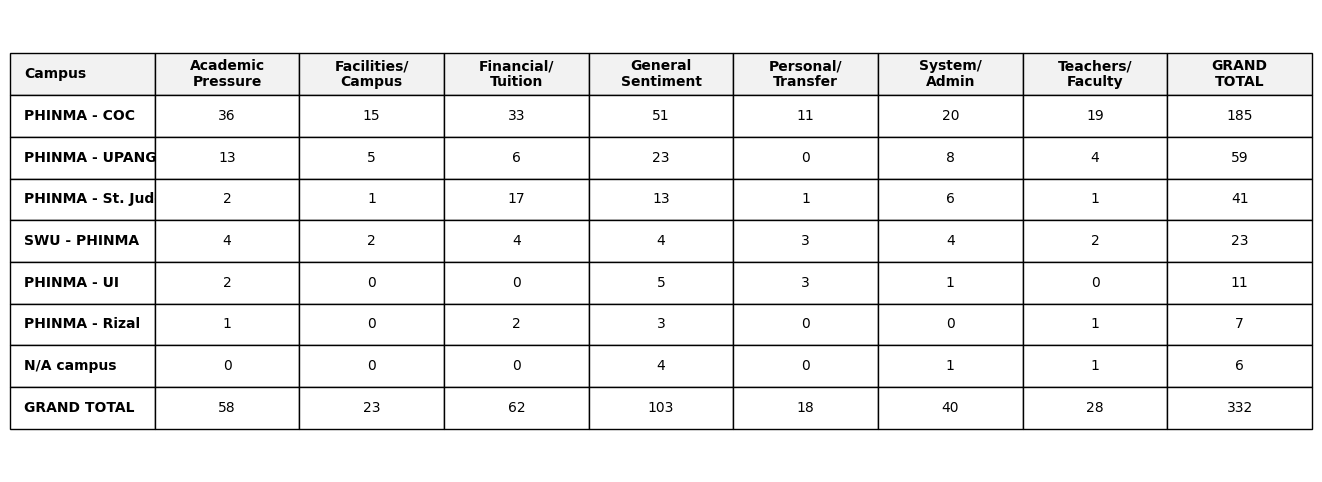

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the data exactly as seen in your image
data = [
    ["PHINMA - COC", 36, 15, 33, 51, 11, 20, 19, 185],
    ["PHINMA - UPANG", 13, 5, 6, 23, 0, 8, 4, 59],
    ["PHINMA - St. Jude", 2, 1, 17, 13, 1, 6, 1, 41],
    ["SWU - PHINMA", 4, 2, 4, 4, 3, 4, 2, 23],
    ["PHINMA - UI", 2, 0, 0, 5, 3, 1, 0, 11],
    ["PHINMA - Rizal ", 1, 0, 2, 3, 0, 0, 1, 7],
    ["N/A campus", 0, 0, 0, 4, 0, 1, 1, 6],
    ["GRAND TOTAL", 58, 23, 62, 103, 18, 40, 28, 332]
]

# Using \n to wrap column names so they are easy to read
columns = [
    "Campus", 
    "Academic\nPressure", 
    "Facilities/\nCampus", 
    "Financial/\nTuition", 
    "General\nSentiment", 
    "Personal/\nTransfer", 
    "System/\nAdmin", 
    "Teachers/\nFaculty", 
    "GRAND\nTOTAL"
]

df = pd.DataFrame(data, columns=columns)

# 2. Create the table visualization
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('tight')
ax.axis('off')

# Render the table
table = ax.table(cellText=df.values,
                 colLabels=df.columns,
                 cellLoc='center',
                 loc='center')

# 3. Apply Styling (White background, Clear headers)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.5) # Expands row height for better legibility

for (row, col), cell in table.get_celld().items():
    if row == 0: # Style the Header
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f2f2f2') # Light grey header
    if col == 0: # Style the Campus column (Left aligned)
        cell.set_text_props(weight='bold', ha='left')
    if row > 0: # Data cells background
        cell.set_facecolor('white')

# 4. Save and show
plt.savefig('campus_table.png', bbox_inches='tight', dpi=300)
plt.show()

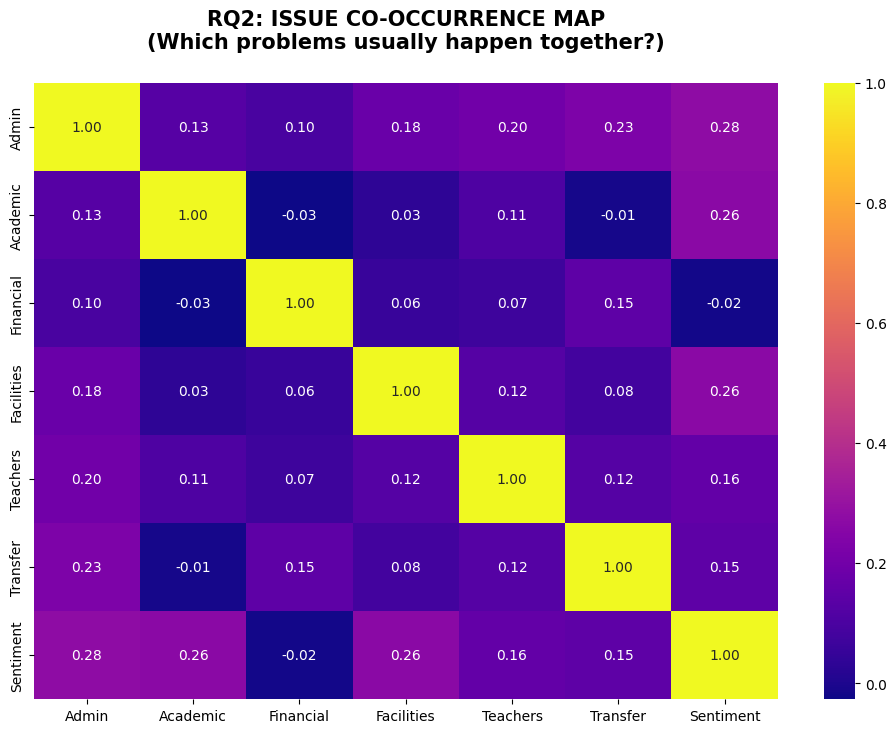

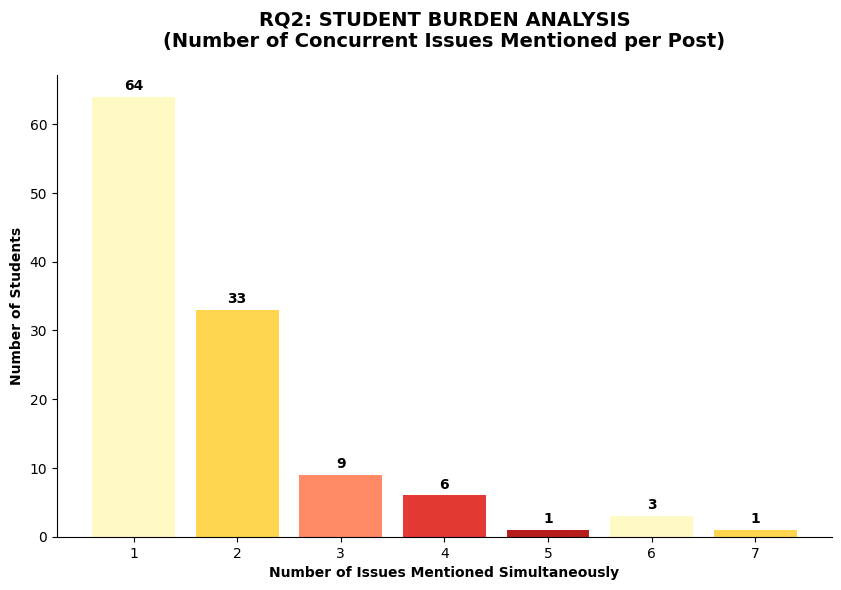


RQ2 INSIGHTS: THE CLUSTER EFFECT
TOP 3 ISSUE CLUSTERS (These issues drive each other):
 - Admin & Sentiment: 0.28 correlation strength
 - Sentiment & Facilities: 0.26 correlation strength
 - Sentiment & Academic: 0.26 correlation strength

CRITICAL INSIGHT: 32.7% of students are leaving due to MULTIPLE issues, not just one.


In [ ]:
"""
RQ2: THE "WHY" - ISSUE CO-OCCURRENCE & IMPACT ANALYSIS
Analyzing how dropout drivers overlap to create high-risk scenarios.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

# 1. SETUP CATEGORIES (Same 7 for consistency)
categories = {
    "Admin": ["system", "admin", "enrollment", "registrar", "portal", "slow", "process", "pila"],
    "Academic": ["pressure", "hard", "difficult", "exam", "board", "fail", "stress", "study"],
    "Financial": ["tuition", "cost", "expensive", "fee", "money", "scholarship", "payment", "balance"],
    "Facilities": ["crowded", "hot", "building", "facilities", "room", "wifi", "aircon", "maintenance"],
    "Teachers": ["professor", "teacher", "instructor", "faculty", "teaching", "prof", "neglectful"],
    "Transfer": ["transfer", "shift", "dropped", "quit", "moved", "other school", "umalis", "lilipat"],
    "Sentiment": ["experience", "feel", "atmosphere", "culture", "vibe", "management", "overall"]
}

# 2. CREATE BINARY MATRIX (Did a post mention this category? 1 or 0)
df_rq2 = df.copy()
for cat, kws in categories.items():
    df_rq2[cat] = df_rq2['translated_text'].apply(
        lambda x: 1 if any(re.search(rf"\b{re.escape(k)}\b", str(x).lower()) for k in kws) else 0
    )

# 3. CALCULATE CORRELATION (Issue Overlap)
# This shows if people who complain about Financial stuff also complain about Admin
corr_matrix = df_rq2[list(categories.keys())].corr()

# 4. PLOT 1: THE OVERLAP HEATMAP (Pretty Purple-Yellow Gradient)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='plasma', fmt=".2f", linewidths=0, cbar=True)
plt.title("RQ2: ISSUE CO-OCCURRENCE MAP\n(Which problems usually happen together?)", 
          fontsize=15, fontweight='bold', pad=25)
plt.show()

# 5. PLOT 2: THE "COMPOUND BURDEN" ANALYSIS
# How many students are facing 1 issue vs 2 issues vs 3+ issues?
df_rq2['issue_count'] = df_rq2[list(categories.keys())].sum(axis=1)
burden_counts = df_rq2['issue_count'].value_counts().sort_index().drop(0, errors='ignore')

plt.figure(figsize=(10, 6))
colors = ["#FFF9C4", "#FFD54F", "#FF8A65", "#E53935", "#B71C1C"] # Saturated gradient
bars = plt.bar(burden_counts.index.astype(str), burden_counts.values, color=colors[:len(burden_counts)])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', fontweight='bold')

plt.title("RQ2: STUDENT BURDEN ANALYSIS\n(Number of Concurrent Issues Mentioned per Post)", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Number of Issues Mentioned Simultaneously", fontweight='bold')
plt.ylabel("Number of Students", fontweight='bold')
sns.despine()
plt.show()

# 6. EXECUTIVE SUMMARY PRINT
print("\n" + "="*80)
print("RQ2 INSIGHTS: THE CLUSTER EFFECT")
print("="*80)
top_corr = corr_matrix.unstack().sort_values(ascending=False).drop_duplicates()
top_corr = top_corr[top_corr < 1.0].head(3)

print("TOP 3 ISSUE CLUSTERS (These issues drive each other):")
for (c1, c2), val in top_corr.items():
    print(f" - {c1} & {c2}: {val:.2f} correlation strength")

multi_issue_pct = (df_rq2[df_rq2['issue_count'] > 1].shape[0] / len(df_rq2)) * 100
print(f"\nCRITICAL INSIGHT: {multi_issue_pct:.1f}% of students are leaving due to MULTIPLE issues, not just one.")

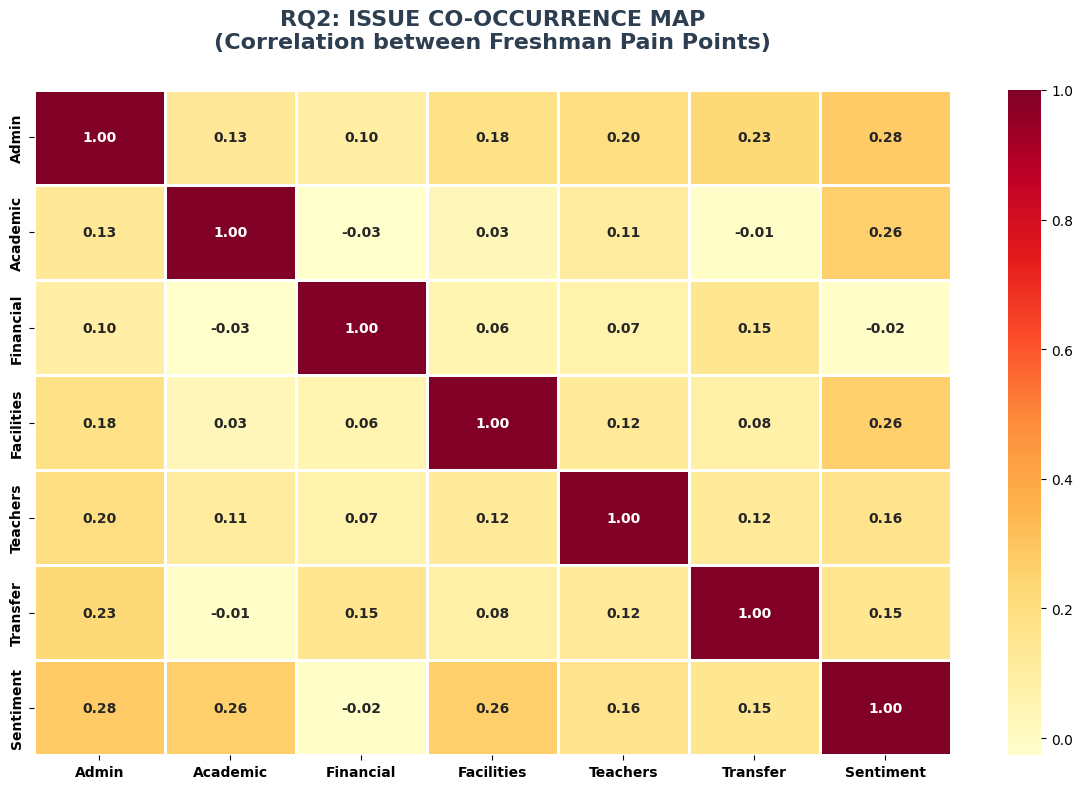

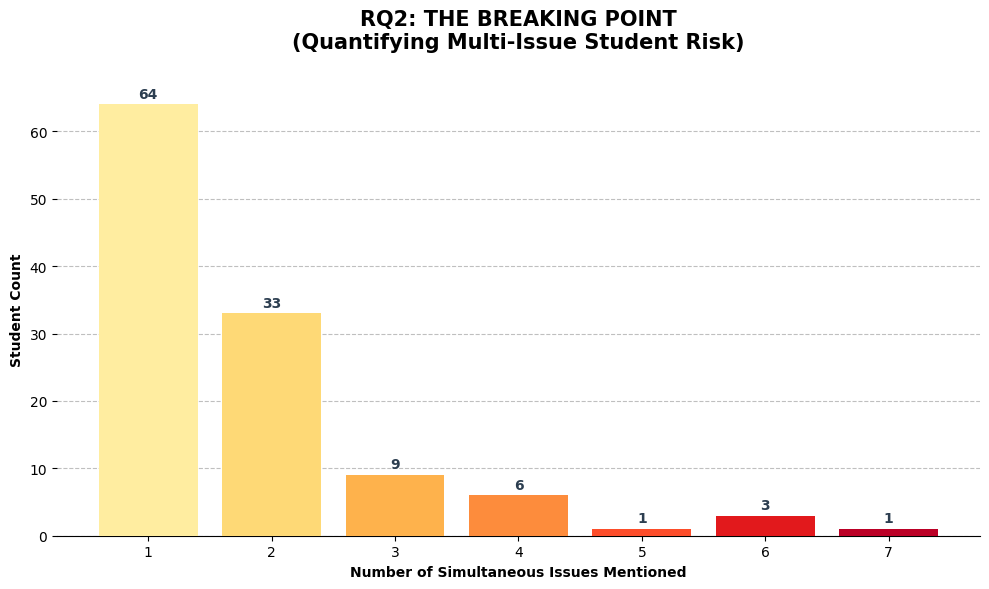


RQ2 INSIGHTS: THE CLUSTER EFFECT
TOP 3 ISSUE CLUSTERS (The 'Chain Reaction' Drivers):
 - Admin & Sentiment: 0.28 correlation strength
 - Sentiment & Facilities: 0.26 correlation strength
 - Sentiment & Academic: 0.26 correlation strength

CRITICAL INSIGHT: 32.7% of students face a 'Multiple Burden' - solving one issue is not enough.


In [ ]:
"""
RQ2: THE "WHY" - ISSUE CO-OCCURRENCE & IMPACT ANALYSIS
Pretty Saturated Red Gradient WITH CLEAN GRIDS
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

# 1. SETUP CATEGORIES (7 Core Drivers)
categories = {
    "Admin": ["system", "admin", "enrollment", "registrar", "portal", "slow", "process", "pila"],
    "Academic": ["pressure", "hard", "difficult", "exam", "board", "fail", "stress", "study"],
    "Financial": ["tuition", "cost", "expensive", "fee", "money", "scholarship", "payment", "balance"],
    "Facilities": ["crowded", "hot", "building", "facilities", "room", "wifi", "aircon", "maintenance"],
    "Teachers": ["professor", "teacher", "instructor", "faculty", "teaching", "prof", "neglectful"],
    "Transfer": ["transfer", "shift", "dropped", "quit", "moved", "other school", "umalis", "lilipat"],
    "Sentiment": ["experience", "feel", "atmosphere", "culture", "vibe", "management", "overall"]
}

# 2. CREATE BINARY MATRIX
df_rq2 = df.copy()
for cat, kws in categories.items():
    df_rq2[cat] = df_rq2['translated_text'].apply(
        lambda x: 1 if any(re.search(rf"\b{re.escape(k)}\b", str(x).lower()) for k in kws) else 0
    )

# 3. CALCULATE CORRELATION
corr_matrix = df_rq2[list(categories.keys())].corr()

# 4. PLOT 1: THE OVERLAP HEATMAP (Clean Grid + Red Gradient)
plt.figure(figsize=(12, 8))

# Using sns.heatmap allows for 'linewidths' which adds a clean divider grid
# We use 'YlOrRd' for that pretty saturated look
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='YlOrRd', 
            fmt=".2f", 
            linewidths=2,      # THIS ADDS THE CLEAN WHITE GRID
            linecolor='white', # White looks much better than black
            cbar=True,
            annot_kws={"weight": "bold"})

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.title("RQ2: ISSUE CO-OCCURRENCE MAP\n(Correlation between Freshman Pain Points)", 
          fontsize=16, fontweight='bold', pad=30, color='#2c3e50')
plt.tight_layout()
plt.show()

# 5. PLOT 2: THE "COMPOUND BURDEN" ANALYSIS (Y-Axis Grid)
df_rq2['issue_count'] = df_rq2[list(categories.keys())].sum(axis=1)
burden_counts = df_rq2['issue_count'].value_counts().sort_index().drop(0, errors='ignore')

plt.figure(figsize=(10, 6))

# Saturated gradient palette
red_palette = sns.color_palette("YlOrRd", len(burden_counts))

bars = plt.bar(burden_counts.index.astype(str), burden_counts.values, color=red_palette)

# ADDING A SUBTLE HORIZONTAL GRID
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray', zorder=0)
# Ensure bars stay in front of the grid
for bar in bars:
    bar.set_zorder(3)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), 
             ha='center', fontweight='bold', color='#2c3e50', zorder=4)

plt.title("RQ2: THE BREAKING POINT\n(Quantifying Multi-Issue Student Risk)", 
          fontsize=15, fontweight='bold', pad=25)
plt.xlabel("Number of Simultaneous Issues Mentioned", fontweight='bold')
plt.ylabel("Student Count", fontweight='bold')

sns.despine(left=True) # Makes it look more like a clean dashboard
plt.tight_layout()
plt.show()

# 6. EXECUTIVE SUMMARY
print("\n" + "="*80)
print("RQ2 INSIGHTS: THE CLUSTER EFFECT")
print("="*80)
top_corr = corr_matrix.unstack().sort_values(ascending=False).drop_duplicates()
top_corr = top_corr[top_corr < 1.0].head(3)

print("TOP 3 ISSUE CLUSTERS (The 'Chain Reaction' Drivers):")
for (c1, c2), val in top_corr.items():
    print(f" - {c1} & {c2}: {val:.2f} correlation strength")

multi_issue_pct = (df_rq2[df_rq2['issue_count'] > 1].shape[0] / len(df_rq2)) * 100
print(f"\nCRITICAL INSIGHT: {multi_issue_pct:.1f}% of students face a 'Multiple Burden' - solving one issue is not enough.")